In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
# from ExoRM.get_data import get_data
# get_data()

# from ExoRM.initialize_model import initialize_model
# initialize_model()

# Use these to initialize / update the model

In [3]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = True # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)
data = data[['name', 'radius', 'mass', 'density', 'error']]

data

,name,radius,mass,density,error
0,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562,0.049985
1,55 Cnc e,1.875000,7.990000,1.212113,0.028071
2,BD-14 3065 b,21.590000,3932.000000,0.390711,0.060558
3,CFHTWIR-Oph 98 b,20.848704,2479.061575,0.273558,0.061518
4,CoRoT-1 b,19.223435,390.930900,0.055031,0.049397
...,...,...,...,...,...
960,XO-3 b,13.988832,3759.928900,1.373521,0.036115
961,XO-4 b,15.020060,512.341960,0.151198,0.027186
962,XO-5 b,12.780000,378.200000,0.181188,0.025901
963,XO-7 b,15.356304,225.658169,0.062315,0.032076


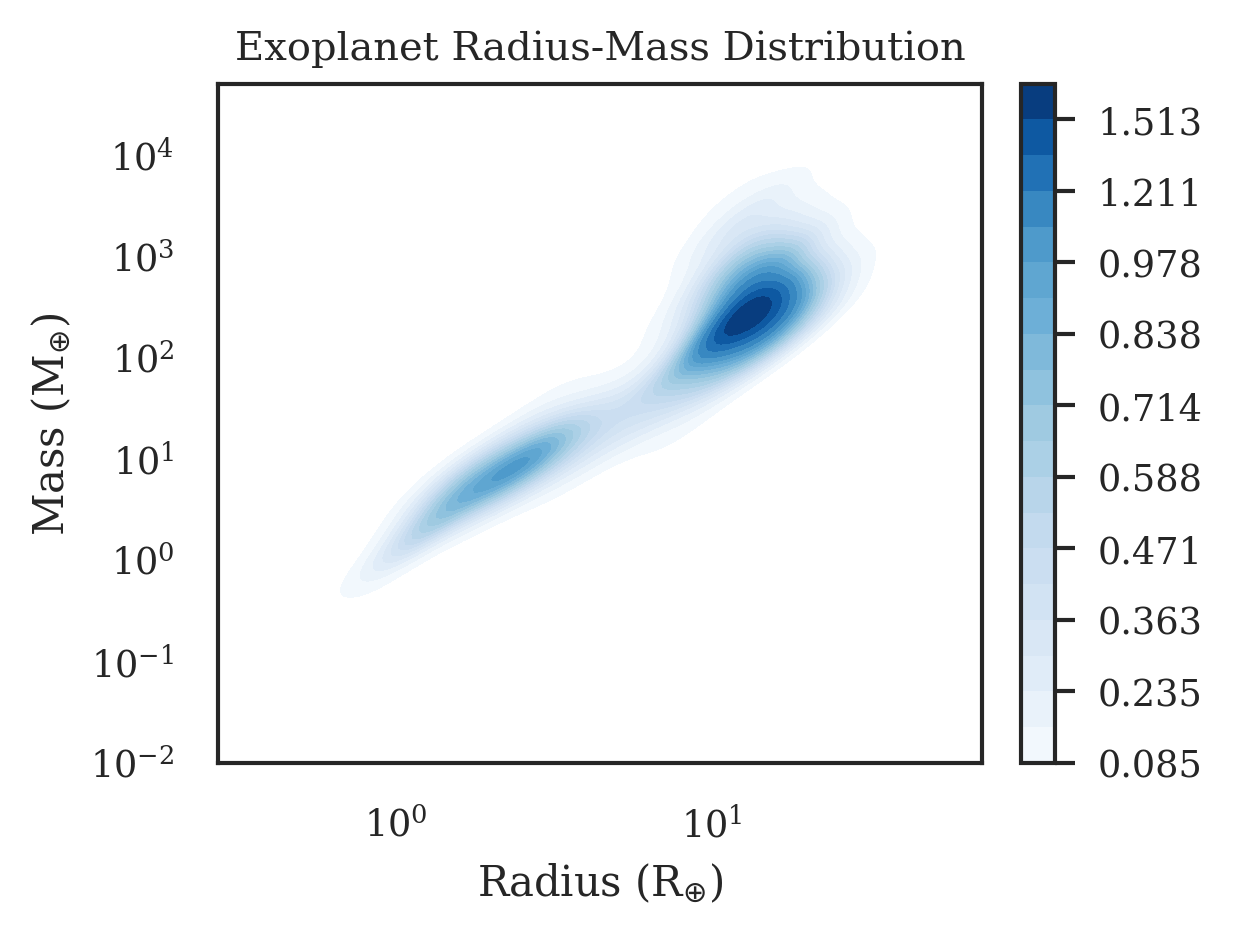

In [4]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
ax = seaborn.kdeplot(data, x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, cbar = True, log_scale = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

# plot.xlim(-0.3, 1.6)
# plot.ylim(-0.75, 4.25)

plot.xlabel('Radius (R$_{\\oplus}$)')
plot.ylabel('Mass (M$_{\\oplus}$)')
plot.title('Exoplanet Radius-Mass Distribution')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

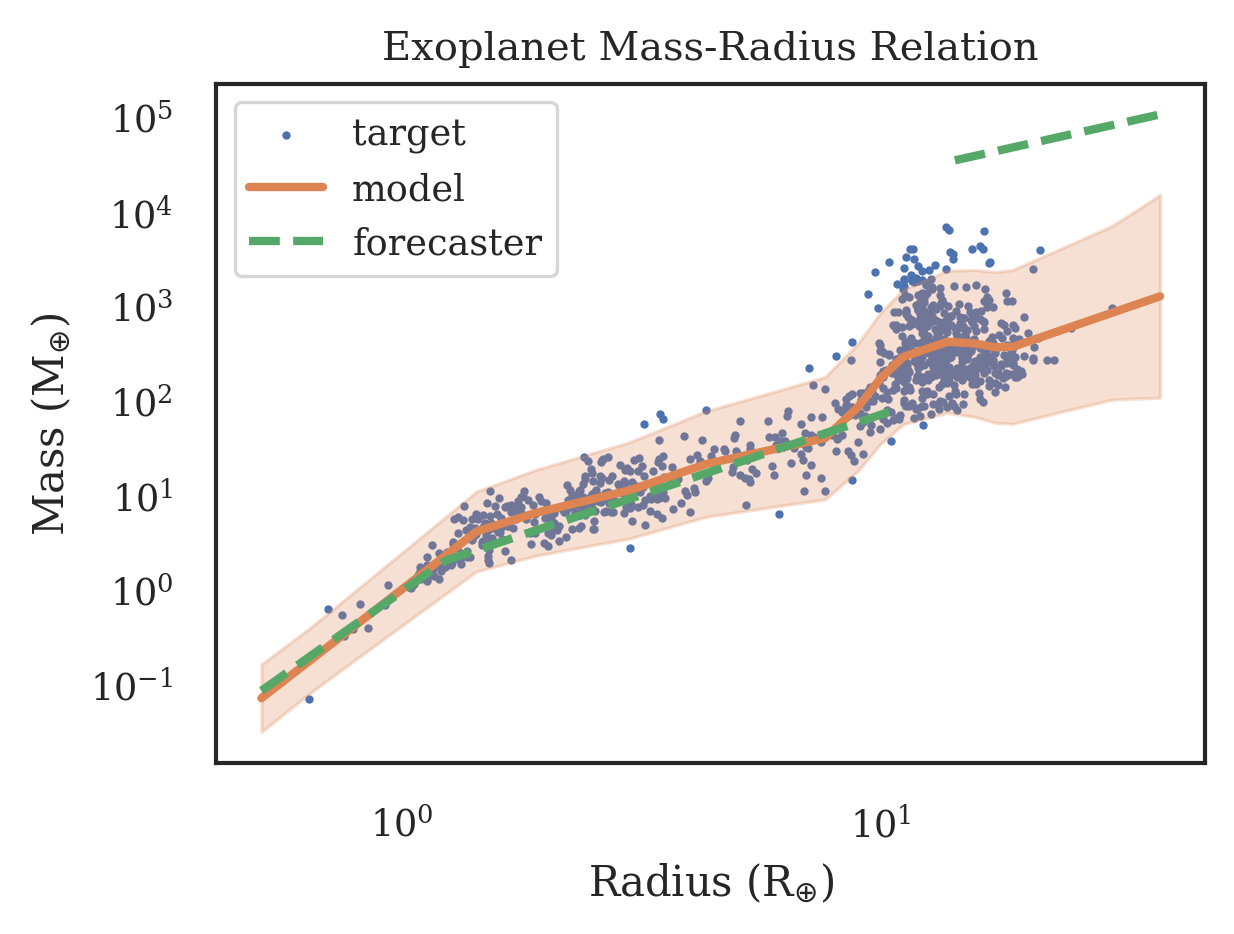

In [5]:
model = load_model()

xs = numpy.linspace(x.min() - 0.1, x.max() + 0.1, 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(10 ** x, 10 ** y)
plot.plot(10 ** xs, 10 ** ms, color = 'C1')
plot.plot(10 ** xs, 10 ** ms2, '--', color = 'C2')

plot.fill_between(10 ** xs, 10 ** (ms - ms_e), 10 ** (ms + ms_e), color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius (R$_{\\oplus}$)')
plot.ylabel('Mass (M$_{\\oplus}$)')
plot.title('Exoplanet Mass-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [6]:
m = model(x)
m_e = model.error(x)
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error / len(x)

0.05284974093264249

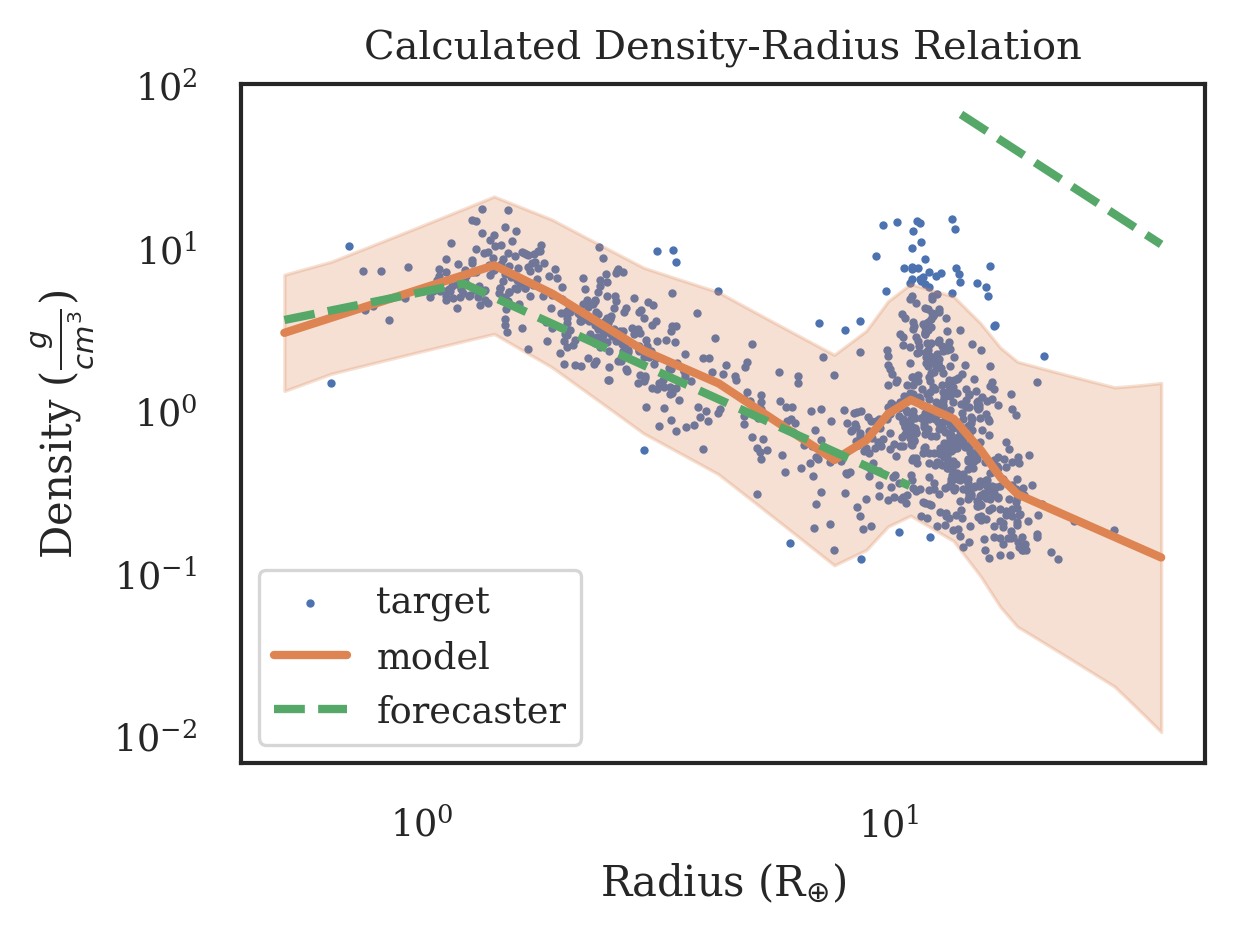

In [7]:
a = numpy.log10(5.51)  # Density of Earth in g / cm^3

plot.scatter(10 ** x, 10 ** ((y - 3 * x) + a))
ds = (ms - 3 * xs) + a
ds2 = (ms2 - 3 * xs) + a
plot.plot(10 ** xs, 10 ** ds, color = 'C1')
plot.plot(10 ** xs, 10 ** ds2, '--', color = 'C2')

plot.fill_between(10 ** xs,
                  10 ** (((ms - ms_e) - 3 * xs) + a),
                  10 ** (((ms + ms_e) - 3 * xs) + a),
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius (R$_{\\oplus}$)')
plot.ylabel('Density (${\\frac{g}{cm^3}}$)')
plot.title('Calculated Density-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

In [8]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.21558761596679688
Forecaster time (ms):  0.2085709571838379


In [9]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])
p_data = p_data[(p_data['radius'] < numpy.log10(11.1))].copy()
p_data = p_data.reset_index(drop = True)
p_data

,name,radius,mass,density,error
0,55 Cnc e,0.273001,0.902547,1.212113,0.028071
1,CoRoT-10 b,1.036339,2.938358,0.675059,0.061723
2,CoRoT-13 b,0.996512,2.618784,0.425843,0.033143
3,CoRoT-20 b,0.974051,3.129542,1.612089,0.051009
4,CoRoT-28 b,1.029570,2.184340,0.124632,0.092767
...,...,...,...,...,...
472,WASP-80 b,1.043444,2.251931,0.132312,0.035178
473,WASP-84 b,1.023623,2.343537,0.187356,0.031869
474,Wolf 327 b,0.093422,0.403121,1.326953,0.115103
475,Wolf 503 b,0.310268,0.796574,0.734124,0.072398


In [10]:
p_data['ExoRM'] = 10 ** model(p_data['radius'])
p_data['Forecaster'] = 10 ** ForecasterRM.forecaster(p_data['radius'])
p_data['l_mass'] = 10 ** p_data['mass']
p_data['ExoRM res'] = (p_data['l_mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['l_mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'l_mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

p_data['winner'] = p_data.apply(
    lambda x: 'ExoRM' if abs(x['ExoRM'] - x['l_mass']) < abs(x['Forecaster'] - x['l_mass']) else 'Forecaster', axis = 1
)

if save: p_data[['name'] + columns + ['winner']].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,error,ExoRM,Forecaster,l_mass,ExoRM res,Forecaster res,winner
0,PH2 b,0.97021,1.939943,0.106982,0.136356,111.6900,63.7180,87.085,-24.60900,23.36700,Forecaster
1,K2-3 b,0.31765,0.708421,0.569488,0.080316,7.3016,4.9698,5.110,-2.19160,0.14016,Forecaster
2,K2-3 d,0.18469,1.045323,3.099193,0.193605,4.6312,2.9554,11.100,6.46880,8.14460,ExoRM
3,K2-18 b,0.41664,0.936011,0.485388,0.094882,9.6251,7.3184,8.630,-0.99509,1.31160,ExoRM
4,K2-19 b,0.84510,1.510545,0.094461,0.040520,36.6330,39.0700,32.400,-4.23260,-6.67030,ExoRM
5,K2-19 c,0.61278,1.033424,0.156701,0.052168,19.7030,15.7550,10.800,-8.90260,-4.95530,Forecaster
6,K2-24 b,0.73239,1.278754,0.120663,0.075097,27.5660,25.1480,19.000,-8.56600,-6.14770,Forecaster
7,K2-24 c,0.87506,1.187521,0.036504,0.080065,39.5090,43.9260,15.400,-24.10900,-28.52600,ExoRM
8,K2-25 b,0.53656,1.389166,0.601853,0.128666,14.4990,11.6950,24.500,10.00100,12.80500,ExoRM
9,K2-27 b,0.65128,1.489958,0.343656,0.100103,22.4640,18.3140,30.900,8.43570,12.58600,ExoRM


In [11]:
p_data['Percent ExoRM err'] = 100 * (((p_data['ExoRM']) - (p_data['l_mass'])) / (p_data['l_mass'])).abs()
p_data['Percent Forecaster err'] = 100 * (((p_data['Forecaster']) - (p_data['l_mass'])) / (p_data['l_mass'])).abs()

p_data['SAPE ExoRM'] = 100 * (((p_data['ExoRM']) - (p_data['l_mass'])) / ((p_data['l_mass'] + p_data['ExoRM']) / 2)).abs()
p_data['SAPE Forecaster'] = 100 * (((p_data['Forecaster']) - (p_data['l_mass'])) / ((p_data['l_mass'] + p_data['Forecaster']) / 2)).abs()

p_data['ExoRM lerr'] = ((p_data['ExoRM']) - (p_data['l_mass'])).abs()
p_data['Forecaster lerr'] = ((p_data['Forecaster']) - (p_data['l_mass'])).abs()

p_data[['Percent ExoRM err', 'Percent Forecaster err', 'SAPE ExoRM', 'SAPE Forecaster', 'ExoRM res', 'Forecaster res', 'ExoRM lerr', 'Forecaster lerr']].abs().describe()

,Percent ExoRM err,Percent Forecaster err,SAPE ExoRM,SAPE Forecaster,ExoRM res,Forecaster res,ExoRM lerr,Forecaster lerr
count,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000
mean,46.992870,42.124646,39.660198,48.980765,43.999686,51.575765,43.999407,51.575594
std,58.574211,38.273304,34.195322,38.776253,198.435777,217.097774,198.433806,217.096174
min,0.176895,0.061789,0.177052,0.061808,0.004864,0.003762,0.004900,0.003800
25%,12.961661,19.131119,12.583668,18.715512,1.019300,1.388800,1.019300,1.388800
50%,31.298718,34.531562,31.313160,38.929355,3.677100,3.972400,3.677100,3.972400
75%,57.493590,55.710667,54.350326,70.517570,14.439000,17.086000,14.439000,17.086200
max,485.369691,388.671875,176.394313,189.867379,2743.700000,2879.000000,2743.690000,2878.979000


In [12]:
p_data['winner'].value_counts() / len(p_data)

winner
ExoRM         0.620545
Forecaster    0.379455
Name: count, dtype: float64

In [13]:
_x = x[x < numpy.log10(11.1)]
numpy.mean(model(_x) - ForecasterRM.forecaster(_x))
# average change metween two models in the < 11.1 radius

0.15737196655072946

In [14]:
comparison = pandas.DataFrame(
    [[10 ** numpy.mean(model(_x)), 10 ** numpy.mean(ForecasterRM.forecaster(_x))],
     [p_data['ExoRM lerr'].mean(), p_data['Forecaster lerr'].mean()],
     [p_data['ExoRM lerr'].max(), p_data['Forecaster lerr'].max()],
     [p_data['Percent ExoRM err'].mean(), p_data['Percent Forecaster err'].mean()],
     [p_data['Percent ExoRM err'].median(), p_data['Percent Forecaster err'].median()],
     [p_data['SAPE ExoRM'].mean(), p_data['SAPE Forecaster'].mean()],
     [100 * p_data['winner'].value_counts()['ExoRM'] / len(p_data), 100 * p_data['winner'].value_counts()['Forecaster'] / len(p_data)]
     ],
    columns = ['ExoRM', 'Forecaster'])

comparison['Difference'] = comparison['ExoRM'] - comparison['Forecaster']

comparison = comparison.map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

if save: comparison.to_csv(f'{path}/filtered_comparison.csv', index = False)

comparison

,ExoRM,Forecaster,Difference
0,16.253,11.313,4.9405
1,43.999,51.576,-7.5762
2,2743.700,2879.000,-135.2900
3,46.993,42.125,4.8682
4,31.299,34.532,-3.2328
5,39.660,48.981,-9.3206
6,62.055,37.945,24.1090


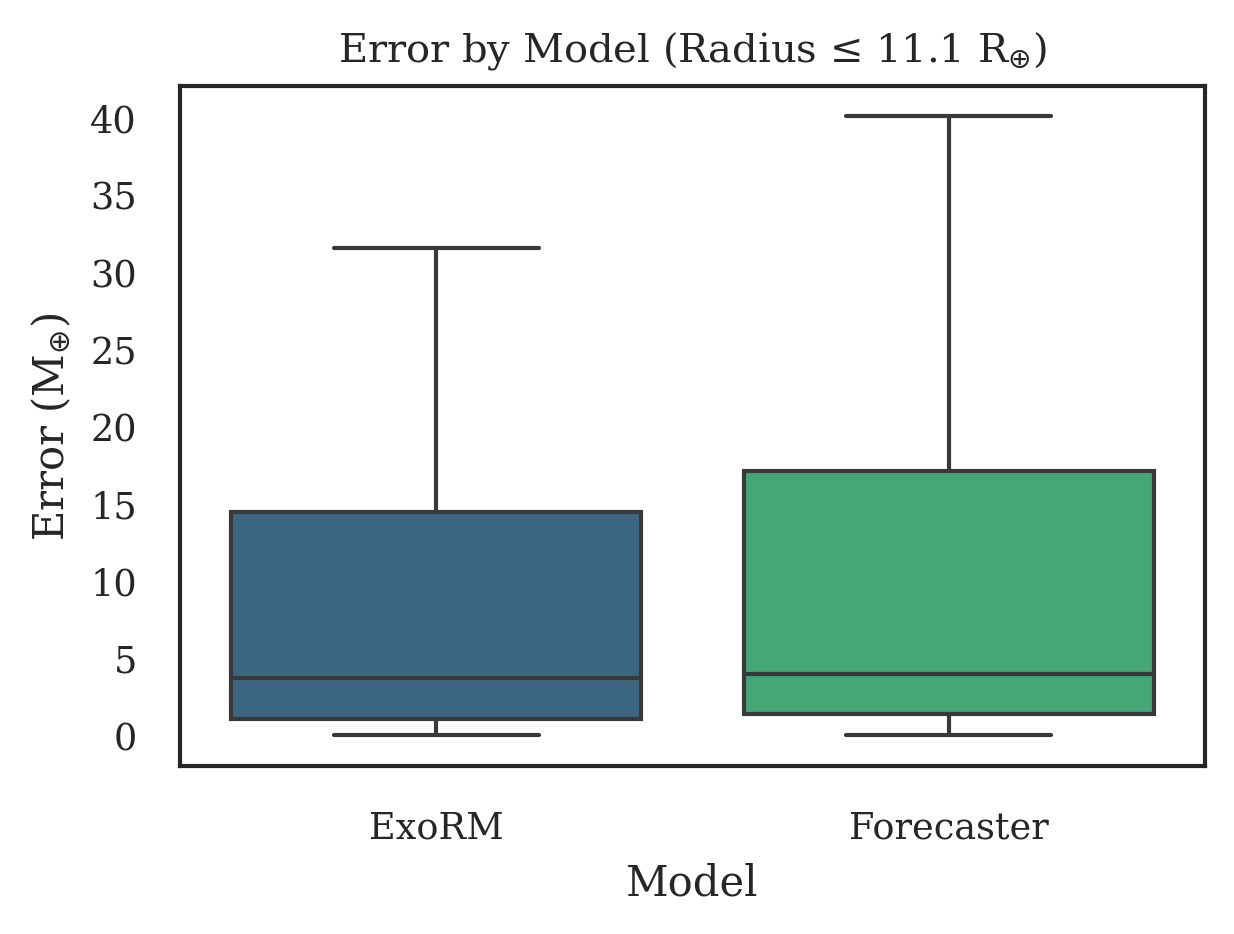

In [20]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['ExoRM lerr', 'Forecaster lerr'],
    var_name = 'Model',
    value_name = 'Error (M$_{\\oplus}$)'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'ExoRM lerr' else 'Forecaster')

ax = seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Error (M$_{\\oplus}$)', hue = 'Model', palette = 'viridis', zorder = 1, whis = 1.5, showfliers = False)

plot.title('Error by Model (Radius ≤ 11.1 R$_{\\oplus}$)')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

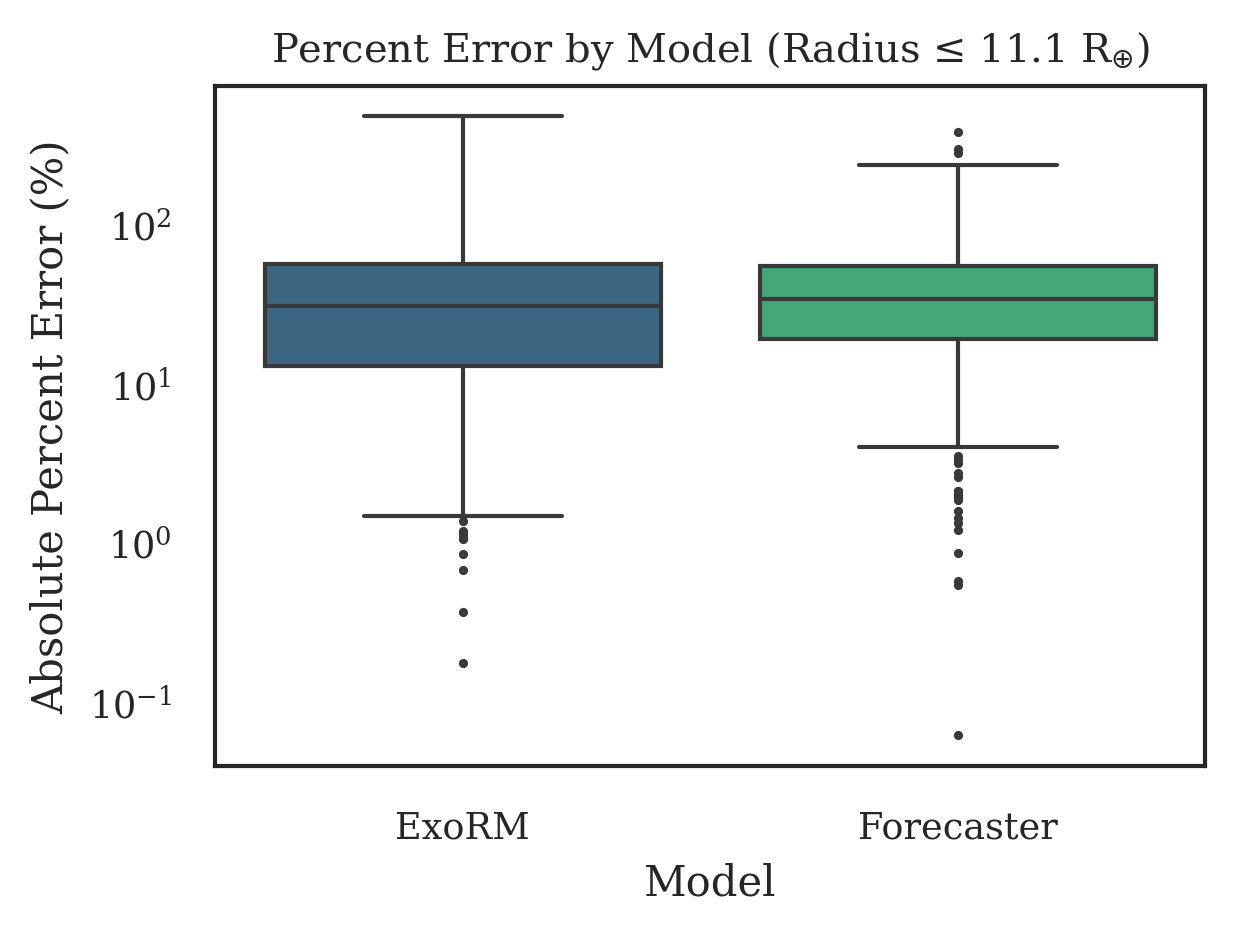

,Model,Absolute Percent Error (%)
0,ExoRM,28.254005
1,ExoRM,42.888454
2,ExoRM,58.277477
3,ExoRM,11.530707
4,ExoRM,13.064815
...,...,...
949,Forecaster,55.769231
950,Forecaster,41.877885
951,Forecaster,49.013714
952,Forecaster,11.015678


In [21]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['Percent ExoRM err', 'Percent Forecaster err'],
    var_name = 'Model',
    value_name = 'Absolute Percent Error (%)'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'Percent ExoRM err' else 'Forecaster')

ax = seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Absolute Percent Error (%)', hue = 'Model', palette = 'viridis', zorder = 1, whis = 1.5, showfliers = True, log_scale = True)

plot.title('Percent Error by Model (Radius ≤ 11.1 R$_{\\oplus}$)')

plot.show()

p_data_long

In [17]:
exoplanet_data = read_rm_data()
exoplanet_data = preprocess_data(exoplanet_data)
new_exoplanet_data = exoplanet_data[exoplanet_data['pl_pubdate'] >= '2018']
old_exoplanet_data = exoplanet_data[exoplanet_data['pl_pubdate'] < '2018']
new_exoplanet_data, old_exoplanet_data

(                 name     radius         mass     error pl_pubdate   density
 1            55 Cnc e   1.875000     7.990000  0.028071    2018-10  1.212113
 2        BD-14 3065 b  21.590000  3932.000000  0.060558    2024-03  0.390711
 3    CFHTWIR-Oph 98 b  20.848704  2479.061575  0.061518    2020-12  0.273558
 11         CoRoT-18 b  12.845514  1048.839000  0.047767    2019-02  0.494828
 17         CoRoT-30 b  11.309881   921.707000  0.075592    2020-03  0.637116
 ..                ...        ...          ...       ...        ...       ...
 931         WASP-76 b  20.781450   284.138596  0.028181    2020-04  0.031659
 956        Wolf 327 b   1.240000     2.530000  0.115103    2024-01  1.326953
 957        Wolf 503 b   2.043000     6.260000  0.072398    2021-12  0.734124
 963            XO-7 b  15.356304   225.658169  0.032076    2024-10  0.062315
 964          pi Men c   2.110000     4.300000  0.093244    2020-10  0.457742
 
 [661 rows x 6 columns],
                           name     r

In [18]:
len(new_exoplanet_data) / len(exoplanet_data)

0.6849740932642487

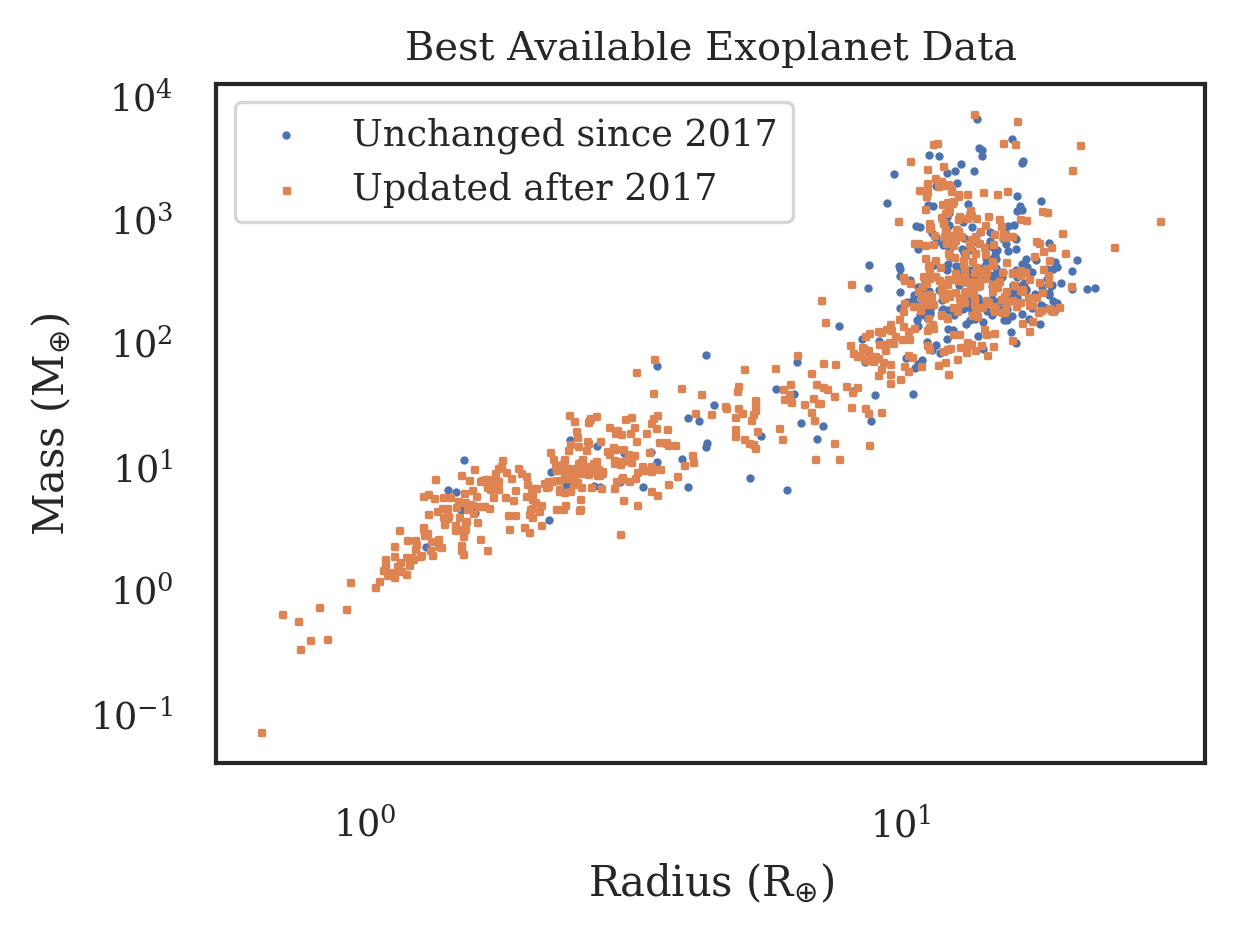

In [19]:
plot.scatter(old_exoplanet_data['radius'], old_exoplanet_data['mass'], marker = 'o')
plot.scatter(new_exoplanet_data['radius'], new_exoplanet_data['mass'], marker = 's')
plot.legend(['Unchanged since 2017', 'Updated after 2017'])

plot.xlabel('Radius (R$_{\\oplus}$)')
plot.ylabel('Mass (M$_{\\oplus}$)')
plot.title('Best Available Exoplanet Data')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()